# Some Data Visualisations 
### (mostly for my understanding of the data)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import squarify

con = duckdb.connect("../db/flight_events.duckdb")

### Show relative frequencies of aircrafts (top 25) in a treemap:

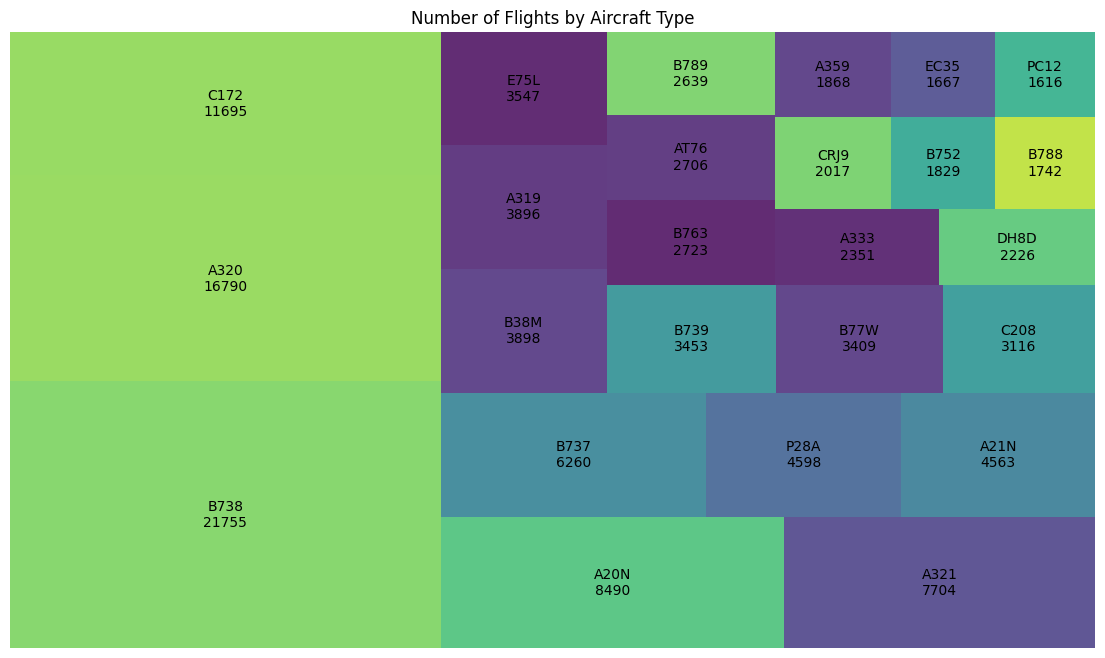

In [2]:
aircraft_types = con.execute("""
SELECT
    equipment,
    COUNT(DISTINCT flight_id) AS flights
FROM flight_events
WHERE equipment IS NOT NULL
  AND equipment <> ''
GROUP BY equipment
ORDER BY flights DESC
""").fetchdf()

top_n = 25
aircraft_types = aircraft_types.head(top_n)

labels = [
    f"{row['equipment']}\n{row['flights']}"
    for _, row in aircraft_types.iterrows()
]

plt.figure(figsize=(14, 8))
squarify.plot(
    sizes=aircraft_types["flights"],
    label=labels,
    alpha=0.85
)

plt.axis("off")
plt.title("Number of Flights by Aircraft Type")
plt.show()

In [3]:
match_check = con.execute("""
SELECT
    COUNT(*) AS total_flights,
    COUNT(*) FILTER (
        WHERE available_capacity_weight IS NOT NULL
          AND available_capacity_volume IS NOT NULL
    ) AS matched_flights,
    COUNT(*) FILTER (
        WHERE available_capacity_weight IS NULL
           OR available_capacity_volume IS NULL
    ) AS unmatched_flights
FROM flight_capacity
""").fetchdf()
match_check

,total_flights,matched_flights,unmatched_flights
0,202407,105461,96946


In [4]:
missing_equipment = con.execute("""
SELECT
    equipment,
    COUNT(*) AS flights
FROM flight_capacity
WHERE available_capacity_weight IS NULL
   OR available_capacity_volume IS NULL
GROUP BY equipment
ORDER BY flights DESC
""").fetchdf()

total_missing = con.execute("""
SELECT COUNT(*) AS total_missing_flights
FROM flight_capacity
WHERE available_capacity_weight IS NULL
   OR available_capacity_volume IS NULL
""").fetchdf()

print(missing_equipment)
print(total_missing)

    equipment  flights
0        C172    11695
1        P28A     4598
2         NaN     3586
3        E75L     3547
4        C208     3116
..        ...      ...
628        O1        1
629      AN30        1
630      MRF1        1
631      AC10        1
632      VTOR        1

[633 rows x 2 columns]
   total_missing_flights
0                  96946


In [5]:
daily_capacity = con.execute("""
SELECT
    flight_date,
    origin_iata,
    destination_iata,
    SUM(available_capacity_weight) AS total_capacity_weight,
    SUM(available_capacity_volume) AS total_capacity_volume
FROM flight_capacity
GROUP BY 1, 2, 3
ORDER BY flight_date, total_capacity_weight DESC
""").fetchdf()
daily_capacity

,flight_date,origin_iata,destination_iata,total_capacity_weight,total_capacity_volume
0,2022-10-03,CJU,GMP,1.006045e+06,1030.02192
1,2022-10-03,GMP,CJU,9.851397e+05,1067.21328
2,2022-10-03,DXB,NaN,9.350680e+05,1442.29152
3,2022-10-03,ICN,NaN,9.212707e+05,1533.61920
4,2022-10-03,HND,CTS,8.122398e+05,1269.09360
...,...,...,...,...,...
113179,2022-10-09,NPL,NaN,NaN,NaN
113180,2022-10-09,FAR,GFK,NaN,NaN
113181,2022-10-09,BPN,TRT,NaN,NaN
113182,2022-10-09,TRM,LAS,NaN,NaN


In [6]:
con.execute("""   SELECT metric, flights, pct_of_flights                                                                                                                                                                                                   
   FROM capacity_data_quality_summary                                                                                                                                                                                                       
   ORDER BY                                                                                                                                                                                                                                 
     CASE metric                                                                                                                                                                                                                            
       WHEN 'total_flights' THEN 0                                                                                                                                                                                                          
       WHEN 'matched_full' THEN 1                                                                                                                                                                                                           
       WHEN 'matched_no_volume' THEN 2                                                                                                                                                                                                      
       WHEN 'missing_equipment' THEN 3                                                                                                                                                                                                      
       WHEN 'no_data_on_equipment' THEN 4                                                                                                                                                                                                   
       ELSE 5                                                                                                                                                                                                                               
     END; """).fetchdf()

,metric,flights,pct_of_flights
0,total_flights,202407,100.00
1,matched_full,105461,52.10
2,matched_no_volume,625,0.31
3,missing_equipment,3586,1.77
4,no_data_on_equipment,92735,45.82
